# Exercise 8 - K-Means Clustering

So far, every algorithm we've used (the decision tree, linear regression) was **supervised**: we had a target variable `y` that we were trying to predict, and the algorithm learned from examples where the correct answer was already known.

In this tutorial we'll look at **unsupervised learning** instead. There is no target variable - just a set of observations, and we want the algorithm to discover structure in the data on its own. Specifically, we'll learn about **K-means clustering**, an algorithm that groups data points into `k` clusters based on how similar they are to each other, without ever being told what the "correct" groups are.

We will use the `california-housing-prices` dataset (the same one you loaded from Kaggle) to:
1. Group houses into geographic regions based on their location.
2. Group houses into "profiles" that combine location with income, to see whether wealth forms its own geographic pockets.

In [1]:
# pip install kagglehub[pandas-datasets]
import kagglehub

import pandas as pd
import numpy as np

import matplotlib as mpl

import plotnine as pln
import warnings
from plotnine.exceptions import PlotnineWarning
warnings.filterwarnings("ignore", category=PlotnineWarning)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

%config InlineBackend.print_figure_kwargs = {'facecolor': 'white', 'bbox_inches': 'tight'}
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['savefig.transparent'] = False

In [2]:
dataset_path = kagglehub.dataset_download("camnugent/california-housing-prices")
df = pd.read_csv(f"{dataset_path}/housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


The dataset contains the following columns, one row per California district (a small geographic area):

* `longitude`, `latitude` - the geographic coordinates of the district
* `housing_median_age` - median age of the houses in the district
* `total_rooms`, `total_bedrooms` - total number of rooms/bedrooms in the district
* `population`, `households` - number of people and households living in the district
* `median_income` - median income of households in the district (in tens of thousands of USD)
* `median_house_value` - median house value in the district (in USD) - this was our target in a regression problem, but today we have no target at all
* `ocean_proximity` - a categorical description of the district's location relative to the ocean


`total_bedrooms` has 207 missing values, out of 20,640 rows - about 1% of the data. Since it's such a small fraction, we'll simply drop these rows rather than trying to impute them:

In [3]:
df = df.dropna().reset_index(drop=True)
df.shape

(20433, 10)

## Visualizing the raw data

Each row has a `longitude` and `latitude`, so we can plot every district as a point on a map. Let's color each point by `median_house_value` to get a first feel for the data:

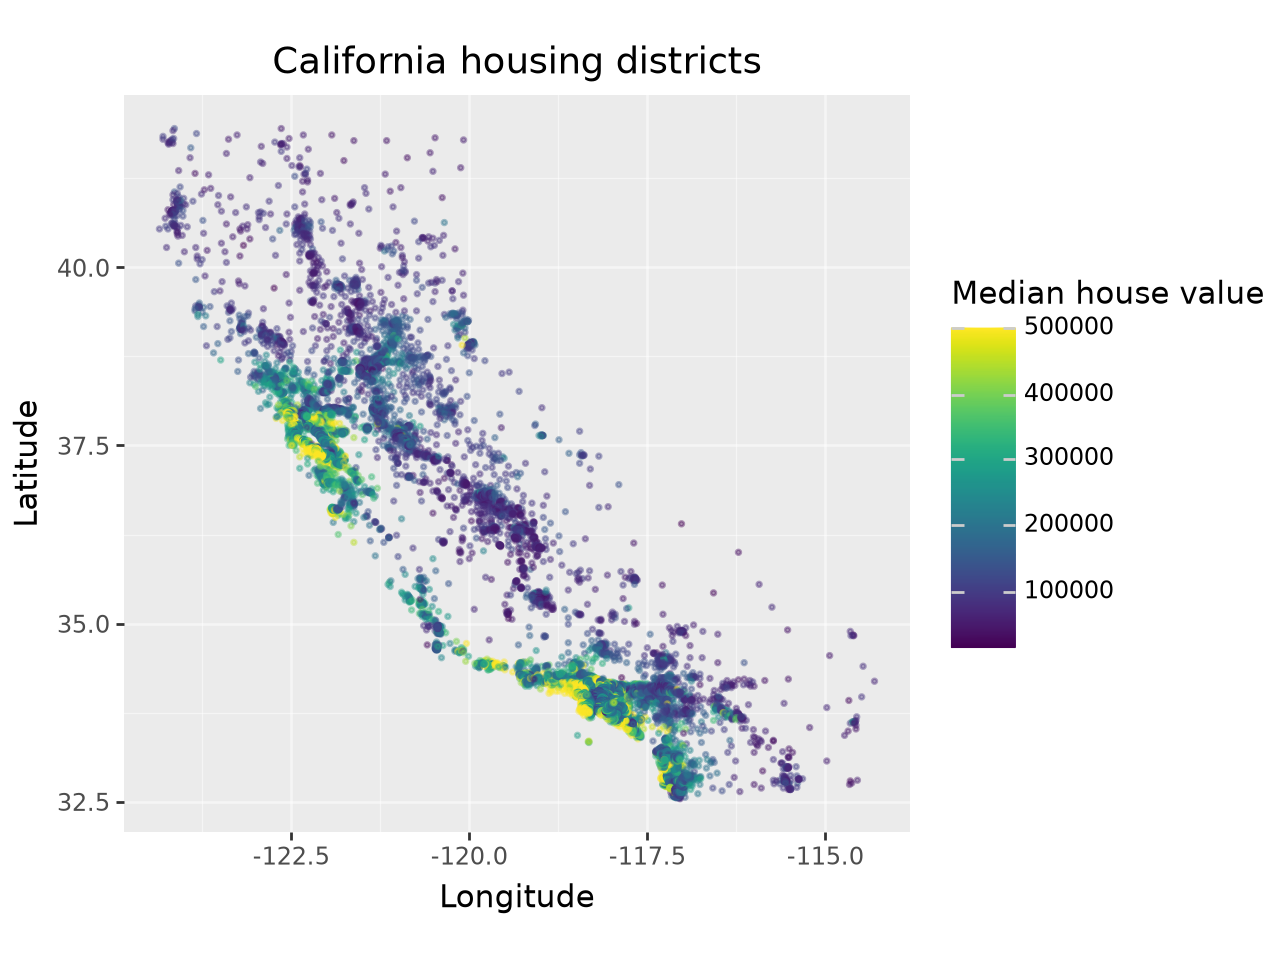

In [18]:
(
    pln.ggplot(df, pln.aes(x='longitude', y='latitude', color='median_house_value'))
    + pln.geom_point(size=0.5, alpha=0.4)
    + pln.scale_color_cmap(cmap_name='viridis')
    + pln.coord_fixed()
    + pln.labs(x='Longitude', y='Latitude', color='Median house value', title='California housing districts')
)

You should recognize the shape of California, with expensive coastal districts (Los Angeles, the Bay Area) standing out in yellow. Looking at this plot, a natural question arises: could an algorithm automatically discover regions like "the Bay Area" or "greater Los Angeles" just from the coordinates, without us telling it where these regions are? This is exactly the kind of question K-means clustering can answer.

## How K-means works

K-means partitions the data into `k` clusters (`k` is a number we choose in advance), such that each point belongs to the cluster whose center (called a **centroid**) it is closest to. It works as follows:

1. **Initialize**: randomly place `k` centroids among the data points.
2. **Assign**: assign every point to its nearest centroid (by straight-line/Euclidean distance).
3. **Update**: move each centroid to the mean position of all the points assigned to it.
4. **Repeat** steps 2-3 until the assignments stop changing (the algorithm has converged).

The algorithm tries to minimize the **inertia** (also called within-cluster sum of squares, WCSS) - the total squared distance between each point and the centroid it's assigned to:

$$ \text{Inertia} = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2 $$

where $C_i$ is the set of points assigned to cluster $i$ and $\mu_i$ is that cluster's centroid. Smaller inertia means the points within each cluster are, on average, closer to their centroid - i.e. tighter, more compact clusters.

Let's try it on the `longitude`/`latitude` columns, with an arbitrary choice of `k=6` to start:

In [4]:
geo = df[['longitude', 'latitude']]

geo_kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['geo_cluster'] = geo_kmeans.fit_predict(geo)

print(f"Inertia: {geo_kmeans.inertia_:.2f}")
df['geo_cluster'].value_counts().sort_index()

Inertia: 7941.58


geo_cluster
0    8802
1    4781
2    1726
3    2306
4    2137
5     681
Name: count, dtype: int64

A couple of notes on the code above:

* `fit_predict` fits the model and directly returns the cluster label (0 to `k-1`) assigned to each row.
* `n_init=10` tells sklearn to run the whole algorithm 10 times, each time starting from a different random set of initial centroids, and keep the best result (lowest inertia). This matters because K-means can converge to a poor solution depending on where the centroids happen to start - running it multiple times makes this much less likely.

You should get an inertia of about **7,941.58**. On its own this number isn't very meaningful (it depends on the scale and units of the data), but it's very useful for *comparing* different values of `k`, as we'll see shortly.

Let's plot the clusters, along with their centroids (the black X marks):

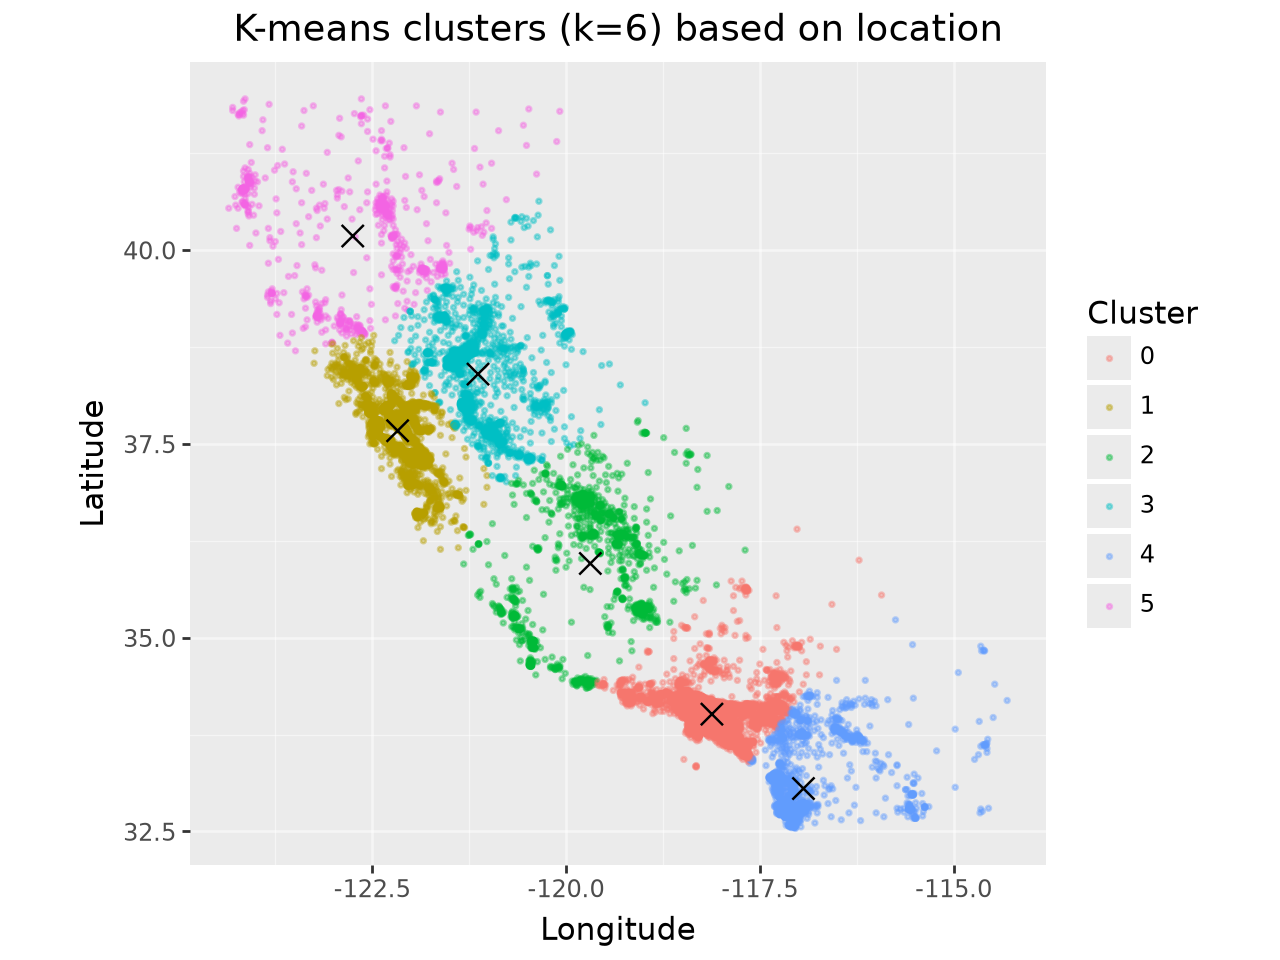

In [20]:
geo_centers = pd.DataFrame(geo_kmeans.cluster_centers_, columns=['longitude', 'latitude'])

(
    pln.ggplot()
    + pln.geom_point(df, pln.aes(x='longitude', y='latitude', color='factor(geo_cluster)'), size=0.5, alpha=0.4)
    + pln.geom_point(geo_centers, pln.aes(x='longitude', y='latitude'), color='black', size=4, shape='x')
    + pln.coord_fixed()
    + pln.labs(x='Longitude', y='Latitude', color='Cluster', title='K-means clusters (k=6) based on location')
)

Even with a somewhat arbitrary `k=6`, the clusters roughly line up with real regions of California: greater Los Angeles, the Bay Area, the far north, the inland southeast (near San Diego/Palm Springs), and the Central Valley split into two clusters.

But we picked `k=6` out of thin air - how do we choose `k` in a more principled way?

## Choosing the number of clusters: the elbow method

As `k` increases, inertia always decreases (more clusters means points are, on average, closer to *some* centroid) - all the way down to 0 when `k` equals the number of data points. So we can't just pick the `k` that minimizes inertia. Instead, the **elbow method** looks at how much inertia improves as `k` increases, and looks for the point where adding more clusters stops helping much - the "elbow" of the curve.

Let's compute the inertia for `k` from 1 to 10:

In [5]:
ks = range(1, 11)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(geo)
    inertias.append(km.inertia_)

elbow_df = pd.DataFrame({'k': list(ks), 'inertia': inertias})
elbow_df

,k,inertia
0,1,175271.942388
1,2,26335.878877
2,3,18096.895559
3,4,14119.508864
4,5,10239.463769
5,6,7941.577287
6,7,6745.851117
7,8,5985.961919
8,9,5226.322149
9,10,4628.400998


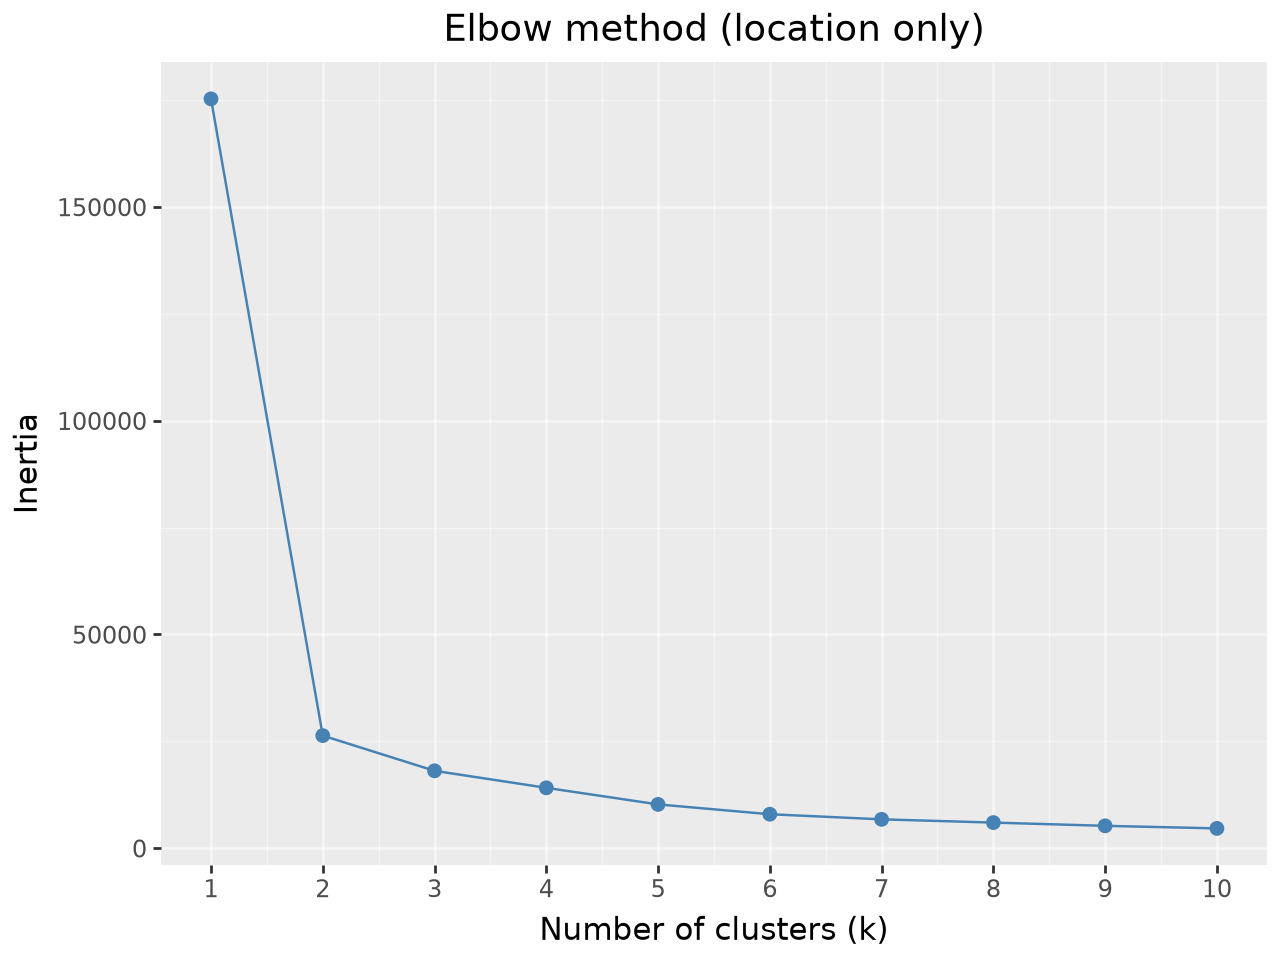

In [10]:
(
    pln.ggplot(elbow_df, pln.aes(x='k', y='inertia'))
    + pln.geom_line(color='steelblue')
    + pln.geom_point(color='steelblue', size=2)
    + pln.scale_x_continuous(breaks=list(ks))
    + pln.labs(x='Number of clusters (k)', y='Inertia', title='Elbow method (location only)')
    # + pln.xlim(2,10) + pln.ylim(0,50000)
)

The curve drops sharply up to around `k=5` or `k=6`, then flattens out - adding a 7th, 8th, 9th cluster keeps helping, but each one buys us less than the last. That flattening point is our "elbow", and it's consistent with the `k=6` we tried above.

The elbow method requires a judgment call (the "elbow" isn't always sharp), so it's useful to check it against another metric: the **silhouette score**. For each point, it compares:

* $a$ = the average distance to the other points in its *own* cluster (lower is better - the point fits well where it is)
* $b$ = the average distance to the points in the *nearest other* cluster (higher is better - the point is far from other clusters)

$$ s = \frac{b - a}{\max(a, b)} $$

This gives a score between -1 and 1 for each point (averaged into a single score for the whole clustering): close to 1 means well-separated, tight clusters, close to 0 means clusters are overlapping, and negative means points are probably in the wrong cluster. Unlike inertia, it's not guaranteed to keep improving as `k` grows, which makes it easier to compare across different values of `k` directly:

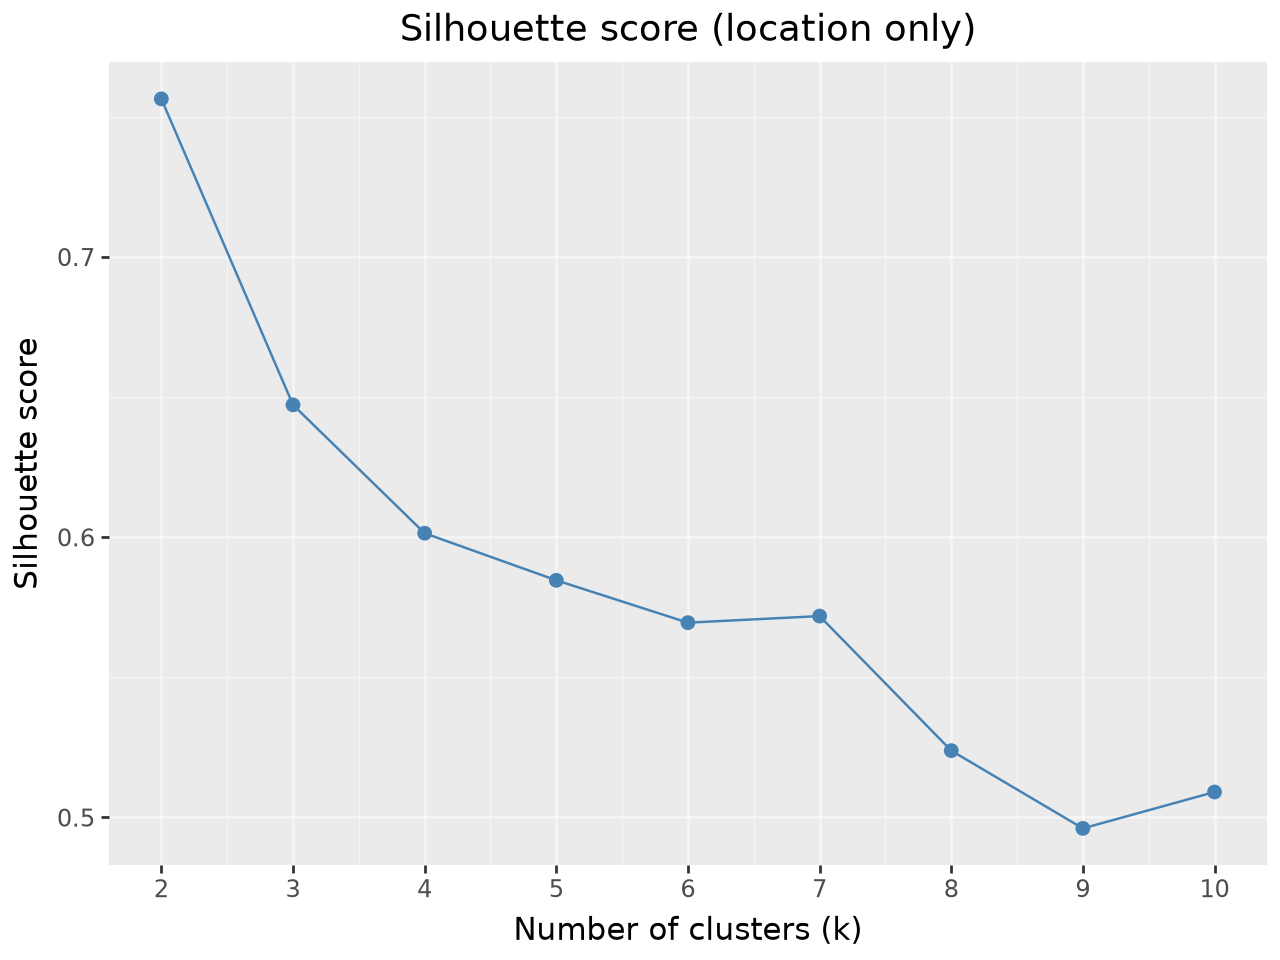

In [23]:
ks_sil = range(2, 11)  # silhouette score needs at least 2 clusters
sil_scores = []

for k in ks_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(geo)
    sil_scores.append(silhouette_score(geo, labels))

sil_df = pd.DataFrame({'k': list(ks_sil), 'silhouette': sil_scores})

(
    pln.ggplot(sil_df, pln.aes(x='k', y='silhouette'))
    + pln.geom_line(color='steelblue')
    + pln.geom_point(color='steelblue', size=2)
    + pln.scale_x_continuous(breaks=list(ks_sil))
    + pln.labs(x='Number of clusters (k)', y='Silhouette score', title='Silhouette score (location only)')
)

Interesting - the silhouette score is actually highest at `k=2` (about **0.76**) and generally decreases from there. This is a good illustration of a real limitation of the silhouette score: it tends to reward a small number of large, well-separated blobs. California is a long, narrow, curved state, so simply splitting it into "north" and "south" produces two very compact, well-separated groups - a high silhouette score, but not a very *useful* clustering for our purposes.

This is why it's best to use these metrics as a guide rather than a strict rule, and combine them with domain knowledge about what a "useful" number of clusters looks like for your problem. Here, the elbow method (and the fact that `k=6` gave us recognizable, useful regions) is more informative than the silhouette score, so we'll stick with `k=6` for the geographic clustering.

## Clustering by location and income

K-means isn't limited to two features - we can just as easily cluster on three (or more) at once. Let's add `median_income` to `longitude` and `latitude`, and cluster on all three together. This lets us ask a more interesting question than before: instead of just splitting California into geographic regions, do wealthy and low-income districts form their own tight geographic pockets *within* those regions?

In [13]:
features = ['longitude', 'latitude', 'median_income']
X = df[features]
X.describe()

,longitude,latitude,median_income
count,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,3.871162
std,2.003578,2.136348,1.899291
min,-124.350000,32.540000,0.499900
25%,-121.800000,33.930000,2.563700
50%,-118.490000,34.260000,3.536500
75%,-118.010000,37.720000,4.744000
max,-114.310000,41.950000,15.000100


Notice that `median_income` lives on a very different scale from `longitude`/`latitude`: coordinates vary by roughly 10 degrees across the whole state, while `median_income` varies by roughly 0.5-15 (i.e. by a factor of 30).

This matters a lot for K-means, because it assigns points to clusters based on **Euclidean distance** across all features at once. If we used the raw values, the small numeric range of `median_income` would mean it barely influences the distance between points compared to `longitude`/`latitude` - the clustering would end up looking almost identical to the location-only clustering we did above, largely ignoring income.

The fix is to **standardize** the features first, using `StandardScaler`: it rescales each column to have mean 0 and standard deviation 1, so that every feature contributes roughly equally to the distance calculation:

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=features).describe()

,longitude,latitude,median_income
count,2.043300e+04,2.043300e+04,2.043300e+04
mean,-8.902214e-16,-1.780443e-15,-1.780443e-16
std,1.000024e+00,1.000024e+00,1.000024e+00
min,-2.385447e+00,-1.447937e+00,-1.775054e+00
25%,-1.112692e+00,-7.972780e-01,-6.884113e-01
50%,5.393926e-01,-6.428050e-01,-1.762077e-01
75%,7.789699e-01,9.768213e-01,4.595713e-01
max,2.625711e+00,2.956885e+00,5.859665e+00


All three columns now have mean ~0 and standard deviation 1. Let's use the elbow method again, this time on the scaled features, to choose `k`:

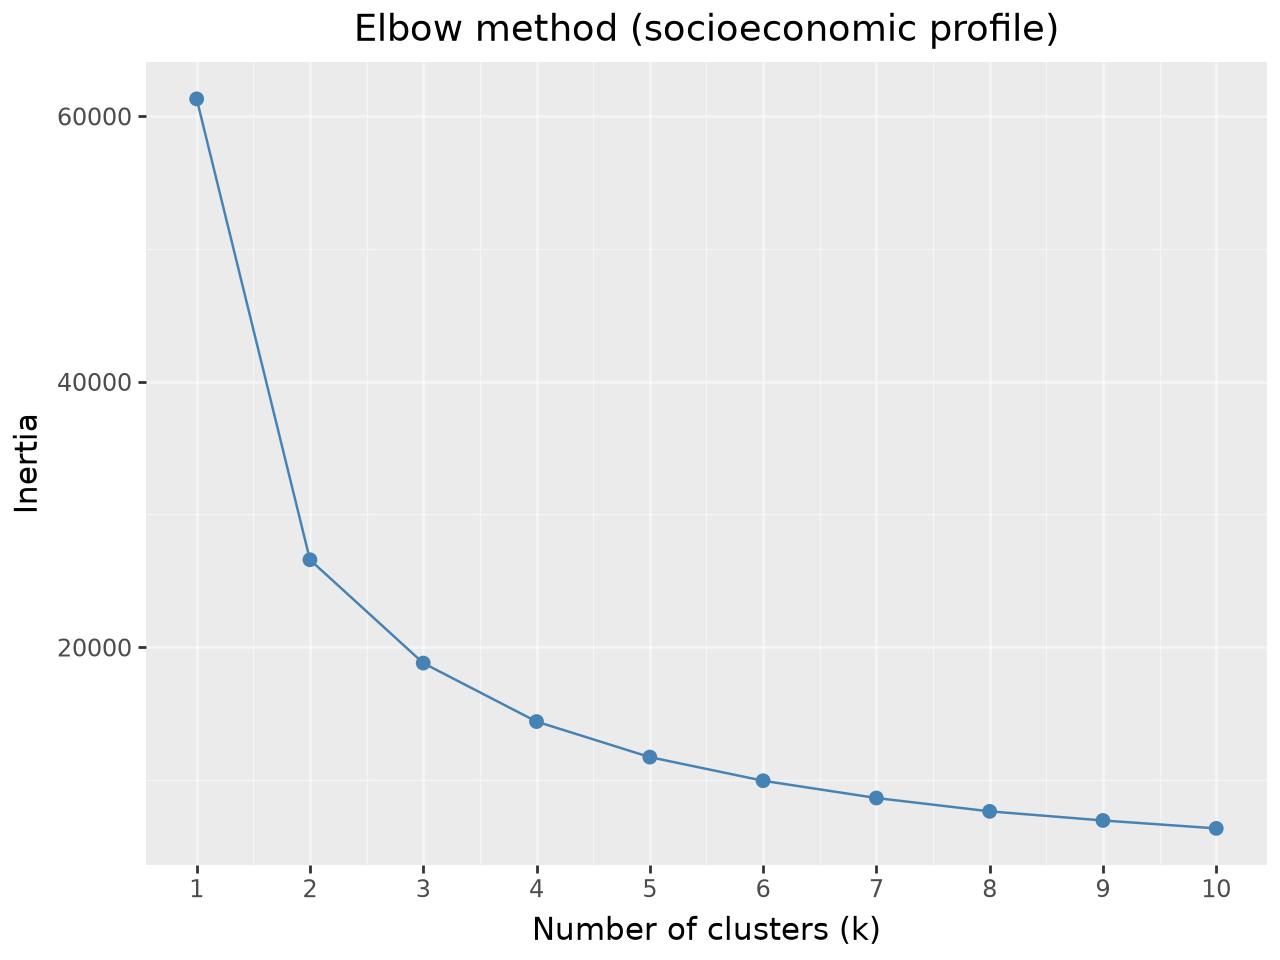

In [15]:
ks = range(1, 11)
inertias_scaled = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias_scaled.append(km.inertia_)

elbow_scaled_df = pd.DataFrame({'k': list(ks), 'inertia': inertias_scaled})

(
    pln.ggplot(elbow_scaled_df, pln.aes(x='k', y='inertia'))
    + pln.geom_line(color='steelblue')
    + pln.geom_point(color='steelblue', size=2)
    + pln.scale_x_continuous(breaks=list(ks))
    + pln.labs(x='Number of clusters (k)', y='Inertia', title='Elbow method (socioeconomic profile)')
)

This curve doesn't have as sharp a bend as the location-only one - it keeps decreasing throughout - but the rate of improvement clearly slows down after about `k=4` or `k=5` (each extra cluster after that buys much less than the ones before it). We'll go with `k=5`, which gives us enough resolution to potentially separate distinct high-income and low-income pockets from each other, as we'll see below.

Since we fit K-means on the *scaled* features, the cluster centers it learns are also in scaled units, which aren't very interpretable on their own. We can use `scaler.inverse_transform` to convert them back into the original units (degrees, tens of thousands of USD) so we can actually interpret them:

In [16]:
profile_kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['profile_cluster'] = profile_kmeans.fit_predict(X_scaled)

centers_scaled = profile_kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

profile_centers = pd.DataFrame(centers_original, columns=features)
profile_centers['count'] = df['profile_cluster'].value_counts().sort_index().values
profile_centers

,longitude,latitude,median_income,count
0,-121.601857,38.107671,2.734590,5465
1,-119.156477,34.826244,10.292585,598
2,-117.983764,33.992653,2.701229,6897
3,-118.025861,33.873290,5.179661,4492
4,-121.927770,37.705094,5.394943,2981


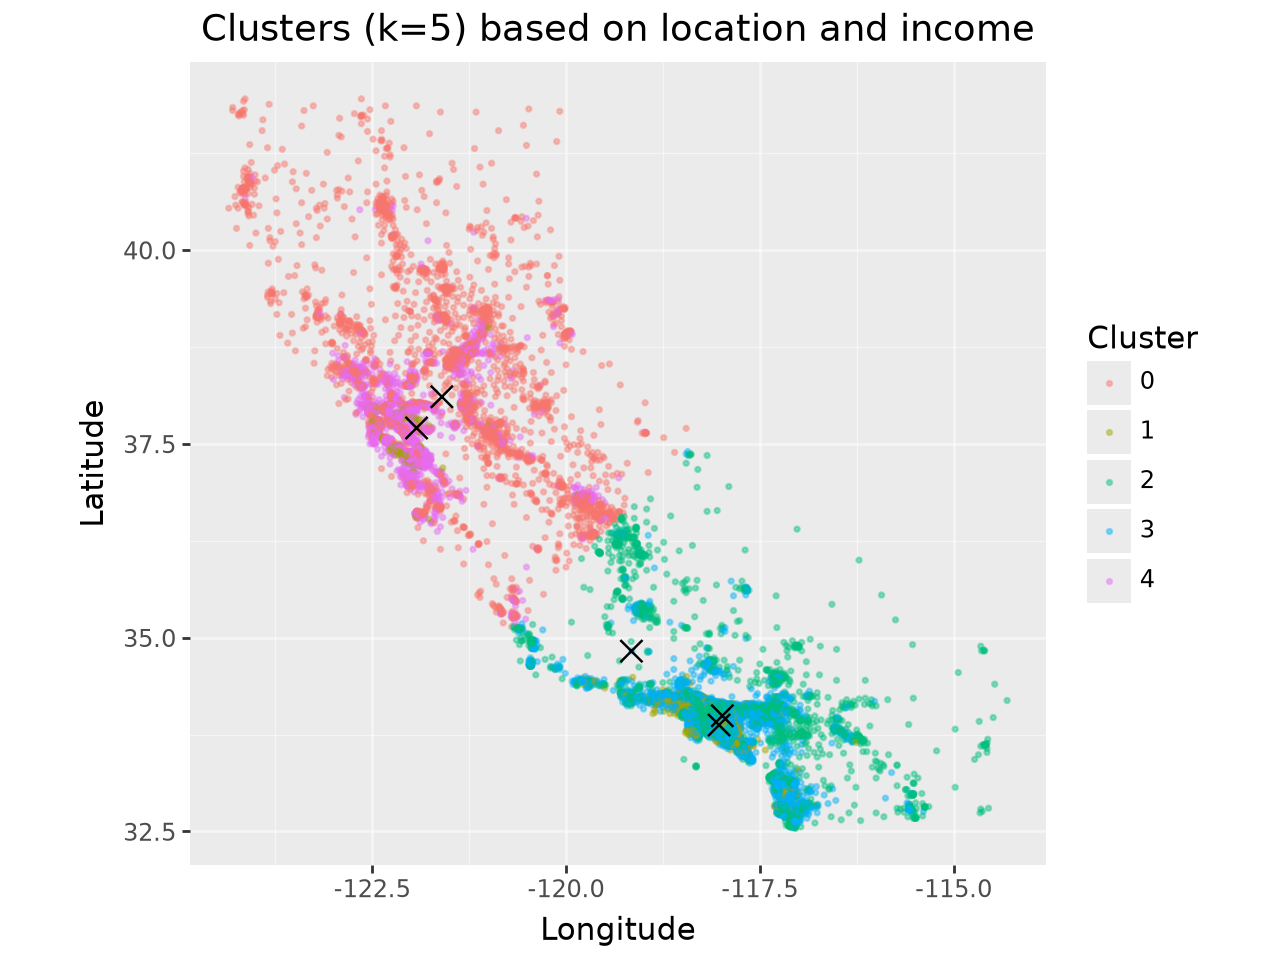

In [17]:
(
    pln.ggplot()
    + pln.geom_point(df, pln.aes(x='longitude', y='latitude', color='factor(profile_cluster)'), size=0.5, alpha=0.4)
    + pln.geom_point(profile_centers, pln.aes(x='longitude', y='latitude'), color='black', size=4, shape='x')
    + pln.coord_fixed()
    + pln.labs(x='Longitude', y='Latitude', color='Cluster', title='Clusters (k=5) based on location and income')
)

We can see that in Northern California, Clusters 0 and 4, along with part of Cluster 1, are dominant, while in Southern California, Clusters 2 and 3, along with part of Cluster 1, are more common.

Now, let’s also look at the income levels associated with each cluster.

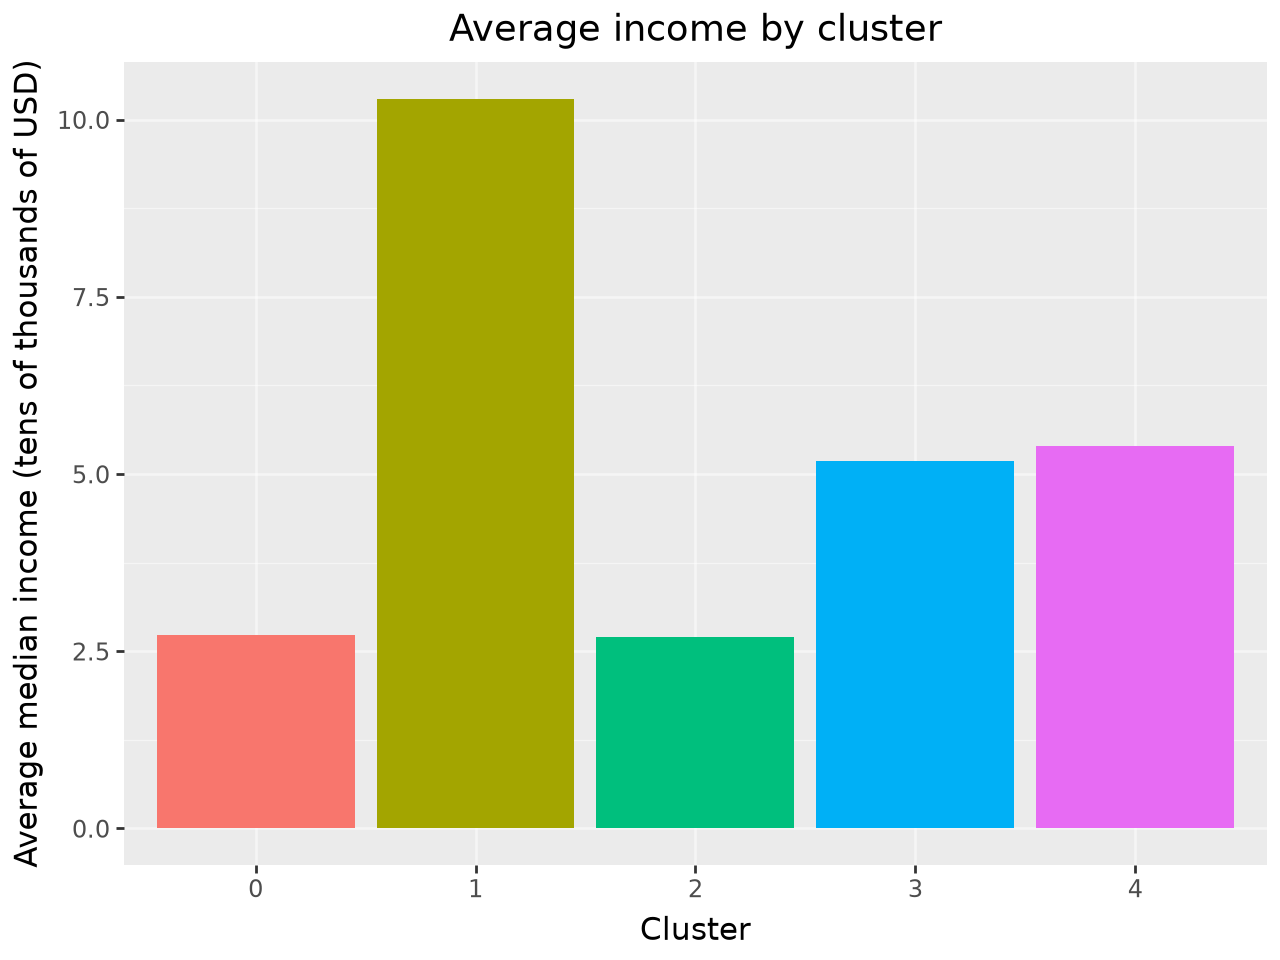

In [30]:
income_by_cluster = profile_centers.reset_index().rename(columns={'index': 'cluster'})

(
    pln.ggplot(income_by_cluster, pln.aes(x='factor(cluster)', y='median_income', fill='factor(cluster)'))
    + pln.geom_col(show_legend=False)
    + pln.labs(x='Cluster', y='Average median income (tens of thousands of USD)', title='Average income by cluster')
    + pln.themes()
)

We can see that Cluster 1 has the highest income level. Interestingly, this cluster tends to appear relatively close to the coast in both Northern and Southern California.
One possible explanation is that coastal areas in California generally have higher housing prices and are often associated with higher-income populations, a pattern that we also observed in the first plot in this tutorial.

The next highest-income clusters are Clusters 3 and 4. In contrast, Clusters 0 and 2 have lower income levels. This may partly explain why these clusters are more common farther inland and in less expensive areas, and less concentrated along the coast.

Overall, the clustering seems to capture not only the geographical separation between Northern and Southern California, but also a meaningful socioeconomic pattern related to income and proximity to the coast.


## Summary

In this tutorial we:

* Learned the difference between supervised learning (with a target `y`) and **unsupervised learning** (finding structure with no target at all).
* Learned how the **K-means** algorithm works: initialize centroids, assign points to the nearest centroid, update centroids to the mean of their assigned points, and repeat until convergence - minimizing **inertia** (within-cluster sum of squares) along the way.
* Clustered districts by `longitude`/`latitude` and visualized the resulting geographic regions.
* Used the **elbow method** and the **silhouette score** to help choose `k`, and saw a case where the silhouette score's preference for well-separated blobs (`k=2`) was less useful than the elbow method's suggestion.
* Learned why **feature scaling** (`StandardScaler`) is essential for K-means when features are on very different scales, since it relies on Euclidean distance across all features.
* Clustered districts by `longitude`, `latitude` and `median_income` together, and interpreted the resulting cluster centers by inverse-transforming them back to their original units.
* Saw how combining a geographic feature with a non-geographic one can reveal patterns - like a small, isolated high-income enclave - that neither feature would reveal on its own.